# ASSETS: AStr211 Synthetic Echelle Training Spectrograph

    Created: Ethan Bull, June 2024
    Edited: Ethan Bull, July 2024

In this notebook you will learn how to reduce data from an echelle spectrograph. The data you will use is a synthesised image containing data from a star that shares parameters from μ Ara.

In [2]:
# Import the python modules you will need. You can use others, but the entire lab can be done with these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
import scipy as sp

%matplotlib inline

# Task 1: Opening and inspecting the data
There are three fits files in the 'data' folder associated with this notebook:
- 'ASSETS_mu_ara.fits'
- 'ASSETS_dark.fits'
- 'ASSETS_thar.fits'. 

These files contain data in the form that an echelle spectrograph would produce. More on echelles in lectures. We will use these files to generate the spectrum of a star (i.e. flux versus wavelength).

Follow these steps to open and display the data from each file:
1. Start with the raw data. Open the fits file using code from Lab 2 or Lab 3.
2. Extract the data from the first extension (1 when indexing in python).
3. Plot the data. Don't forget titles.
4. Repeat steps 1-3 for the dark and thar (thorium) files.

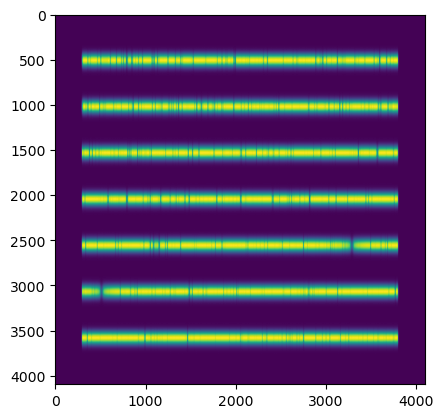

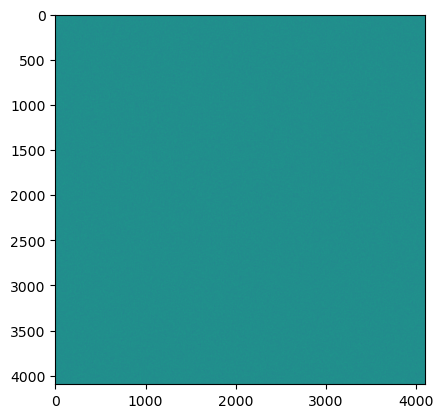

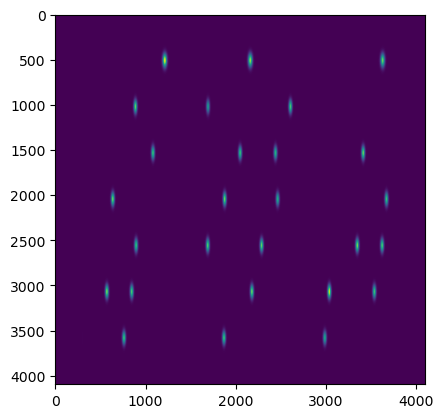

In [9]:
rawfile = 'ASSETS_data/ASSETS_mu_ara.fits'
hdul = fits.open(rawfile)
raw = hdul[1].data 
hdul.close()

plt.imshow(raw)
plt.show()
# Now the dark
darkfile = 'ASSETS_data/ASSETS_dark.fits'
hdul = fits.open(darkfile)
dark = hdul[1].data 
hdul.close()

plt.imshow(dark)
plt.show()
# Now the thorium
tharfile = 'ASSETS_data/ASSETS_thar.fits'
hdul = fits.open(tharfile)
thar = hdul[1].data 
hdul.close()

plt.imshow(thar)
plt.show()


You can clearly see how the 'raw' spectrum has been split up into multiple parallel 'orders'. Now it's time to start reducing the data. 

# Task 2: Reducing and order tracing

First we will do a minimal reduction of the raw image by subtracting the dark from the raw image. Then we will inspect the orders in the reduced raw image and try to trace them.

Follow these steps:

1. Subtract the dark from the raw image to get the reduced raw image.
2. Extract a column slice from the reduced raw image.
3. Plot the column slice to visually confirm where the orders are located in the reduced raw image.
4. Below is an example of using scipy's signal.find_peaks. This function will return index values at the location of the peaks in the column slice.
5. Overplot vertical lines using plt.axvline on your column slice plot using the indices returned by find_peaks.
6. Replot your reduced raw image.
7. Overplot horizontal lines using plt.axhline on your reduced raw image.

In [ ]:
# Example usage of sp.signal.find_peaks
order_pixel_values, order_info = sp.signal.find_peaks(vertical_slice, height=2000, distance=100)

In [ ]:
reduced_raw = 

You have just traced your orders! 

Normally orders are not straight lines and you would have to fit a polynomial to your orders to do the tracing.

# Task 3: Extracting one order

We will focus on extracting and wavelength calibrating one order.

Scipy's find_peaks has returned a list of seven indices that corresponds to the seven orders in the reduced raw image. You will pick one of these orders and extract the flux in that order, first from the reduced raw image and then the thorium image.

Follow these steps:

1. Pick one of the orders that contain the hydrogen alpha (H-alpha) line, which is the thickest absorption line you can see. The H-alpha line is in both orders 5 and 6. Why is it in multiple orders? Discuss with a tutor. 
2. Your order number corresponds to an index that you can use to retrieve the row location of the order in the images. Remember that python indexing starts at 0, but we count the orders from 1. Extract the row location of your order.
3. Extract the flux of your order from your reduced raw image using a row slice.
4. Plot your order.
5. Repeat steps 3 and 4 for the thorium image.

You now have the flux for your order from your reduced raw image and from your thorium image in pixel-space.

# Task 4: Navigating a ThAr Atlas


The thorium image is the a map between pixel-space and wavelength-space. This is because when a Thorium-Argon lamp is heated, it emits light at precise, well-known wavelengths that are well-distributed throughout the spectrum. 

You then use a Thorium-Argon (ThAr) Atlas to impose wavelengths on the order in your thorium image. The Atlas we will use is the ThAr_linelist.txt found in the data folder. This linelist tells you which ThAr lines are in which orders and their corresponding wavelengths.

Follow these steps:

1. Print the ThAr linelist to inspect its column names and contents. 
2. Using your order number, extract the list of ThAr lines in your order. 

There are a variety of ways to do this:
- Pandas masking: You can generate a list of True or False values to use as a mask to reduce the pandas dataframe to your required lines. Ask a tutor if you would like to learn how to do this.
- List comprehension or loops: Loop over the rows of the dataframe either with a For loop, or using comprehension, to test each row to see if it meets your condition i.e. order == order number or order2 == order number.
- Manual: Copy and paste the wavelengths for your order into a vector. This will be tricky if processing multiple orders.

NOTE: This list MUST be in wavelength order.

In [ ]:
linelist = pd.read_csv('path to linelist', sep = ' ',index_col=0)


# Task 5: Mapping pixels to wavelengths

Now, you need to convert from pixel-space to wavelength-space. 

Follow these steps:
1. Use scipy's signal.find_peaks again to extract the pixel positions of the thorium lines in your order. Remember to adjust the height and distance arguments so you extract all pixel values. 
2. Plot the thorium order again and overplot vertical lines at the pixel positions of each ThAr line.

Do you have the same number of pixel values as you do thorium lines in your order? If not, discuss with tutor.


We will now build a linear equation to convert pixels to wavelengths using our pixel positions and corresponding ThAr wavelengths.

Follow these steps:

1. Use np.polyfit with pixel positions as your independant variable and their corresponding ThAr wavelengths as the dependent variable to determine the coefficients for your equation.
2. Make a pixel vector to represent each flux value in your order. HINT: The index of your flux vector is your pixel vector. 
3. Pass your pixel vector and coefficients through np.polyval to return the wavelength vector for your order.
4. Plot your order as flux versus wavelength. Don't forget to add labels.

# Congratulations!

You have successfully wavelength calibrated your order! Now we must check to see if it is correct.

Follow these steps:
1. Overplot the original data from synth_spec.txt and verify the two sets of data align. You may need to modify the scaling of the fluxes.
2. Plot a vertical line using plt.axvline at the centre of the hydrogen line, and another one at 656.28nm. What does this tell us about this spectrum?

# Task 6: Wavelength calibrate all orders

Combine all your code to repeat this process for all 7 orders, and plot them together. How would you produce a full spectrum from this data?